<a href="https://www.kaggle.com/code/fatihsoyalp/ted-talks-data-analysis?scriptVersionId=92614306" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ted-talks/data.csv


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/kaggle/input/ted-talks/data.csv")

In [4]:
df.head()

,title,author,date,views,likes,link
0,Climate action needs new frontline leadership,Ozawa Bineshi Albert,December 2021,404000,12000,https://ted.com/talks/ozawa_bineshi_albert_cli...
1,The dark history of the overthrow of Hawaii,Sydney Iaukea,February 2022,214000,6400,https://ted.com/talks/sydney_iaukea_the_dark_h...
2,How play can spark new ideas for your business,Martin Reeves,September 2021,412000,12000,https://ted.com/talks/martin_reeves_how_play_c...
3,Why is China appointing judges to combat clima...,James K. Thornton,October 2021,427000,12000,https://ted.com/talks/james_k_thornton_why_is_...
4,Cement's carbon problem — and 2 ways to fix it,Mahendra Singhi,October 2021,2400,72,https://ted.com/talks/mahendra_singhi_cement_s...


In [5]:
df.shape

(5440, 6)

In [6]:
df.describe()

,views,likes
count,5.440000e+03,5.440000e+03
mean,2.061576e+06,6.260762e+04
std,3.567098e+06,1.076468e+05
min,5.320000e+02,1.500000e+01
25%,6.707500e+05,2.000000e+04
50%,1.300000e+06,4.050000e+04
75%,2.100000e+06,6.500000e+04
max,7.200000e+07,2.100000e+06


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5440 entries, 0 to 5439
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   5440 non-null   object
 1   author  5439 non-null   object
 2   date    5440 non-null   object
 3   views   5440 non-null   int64 
 4   likes   5440 non-null   int64 
 5   link    5440 non-null   object
dtypes: int64(2), object(4)
memory usage: 255.1+ KB


In [8]:
df[pd.isnull(df['author'])]

,title,author,date,views,likes,link
3039,Year In Ideas 2015,NaN,December 2015,532,15,https://ted.com/talks/year_in_ideas_2015


In [9]:
df["author"].fillna("Unknown", inplace = True)

In [10]:
df[df['views']==df['views'].max()]

,title,author,date,views,likes,link
5436,Do schools kill creativity?,Sir Ken Robinson,February 2006,72000000,2100000,https://ted.com/talks/sir_ken_robinson_do_scho...


In [11]:
df[df['views']==df['views'].min()]

,title,author,date,views,likes,link
3039,Year In Ideas 2015,Unknown,December 2015,532,15,https://ted.com/talks/year_in_ideas_2015


In [12]:
len(df['author'].unique())

4444

In [13]:
top_10_views = df.nlargest(n=10, columns=['views'])
top_10_views.head()

,title,author,date,views,likes,link
5436,Do schools kill creativity?,Sir Ken Robinson,February 2006,72000000,2100000,https://ted.com/talks/sir_ken_robinson_do_scho...
4084,Your body language may shape who you are,Amy Cuddy,June 2012,64000000,1900000,https://ted.com/talks/amy_cuddy_your_body_lang...
2958,Inside the mind of a master procrastinator,Tim Urban,February 2016,60000000,1800000,https://ted.com/talks/tim_urban_inside_the_min...
4765,How great leaders inspire action,Simon Sinek,September 2009,57000000,1700000,https://ted.com/talks/simon_sinek_how_great_le...
4605,The power of vulnerability,Brené Brown,June 2010,56000000,1700000,https://ted.com/talks/brene_brown_the_power_of...


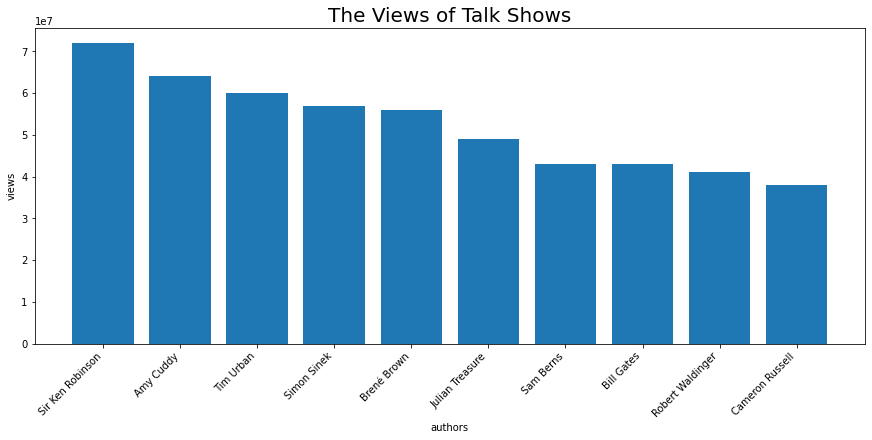

In [14]:
fig, ax = plt.subplots(layout='constrained', figsize=(12,6))
ax.bar(top_10_views['author'],top_10_views['views'])
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')
plt.xlabel('authors')
plt.ylabel('views')
plt.title('The Views of Talk Shows', fontsize=20)
plt.show()

In [15]:
top_10_likes = df.nlargest(n=10, columns=['likes'])
top_10_likes.head()

,title,author,date,views,likes,link
5436,Do schools kill creativity?,Sir Ken Robinson,February 2006,72000000,2100000,https://ted.com/talks/sir_ken_robinson_do_scho...
4084,Your body language may shape who you are,Amy Cuddy,June 2012,64000000,1900000,https://ted.com/talks/amy_cuddy_your_body_lang...
2958,Inside the mind of a master procrastinator,Tim Urban,February 2016,60000000,1800000,https://ted.com/talks/tim_urban_inside_the_min...
4605,The power of vulnerability,Brené Brown,June 2010,56000000,1700000,https://ted.com/talks/brene_brown_the_power_of...
4765,How great leaders inspire action,Simon Sinek,September 2009,57000000,1700000,https://ted.com/talks/simon_sinek_how_great_le...


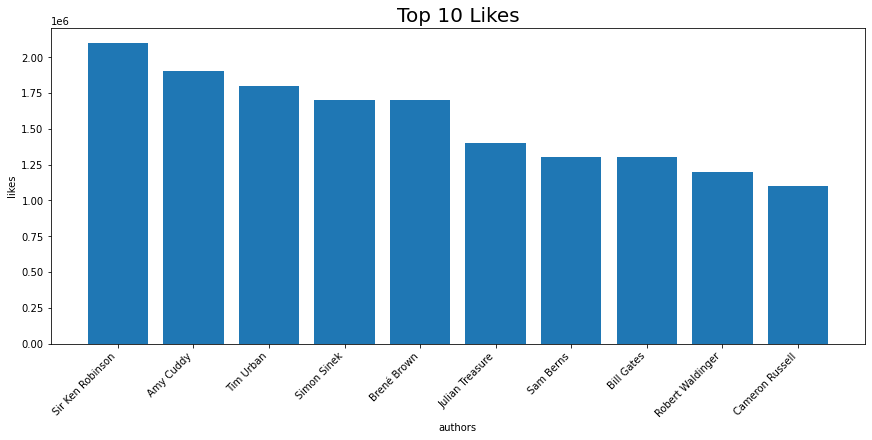

In [16]:
fig, ax = plt.subplots(layout='constrained', figsize=(12,6))
ax.bar(top_10_views['author'],top_10_views['likes'])
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')
plt.title('Top 10 Likes', fontsize=20)
plt.xlabel('authors')
plt.ylabel('likes')
plt.show()

In [17]:
df['percent_of_likes/views'] = (df['likes']/df['views'])*100

In [18]:
top_10_percentange = df.nlargest(n=10, columns=['percent_of_likes/views'])
top_10_percentange.head()

,title,author,date,views,likes,link,percent_of_likes/views
1112,The importance of queer allyship in the classroom,Coby Everton,November 2019,10000,329,https://ted.com/talks/coby_everton_the_importa...,3.290000
1071,Three stories of Scotland,Mackenzie Dalrymple,July 2019,11000,359,https://ted.com/talks/mackenzie_dalrymple_thre...,3.263636
1462,Solar energy can help put power back in the ha...,Scott Nguyen,April 2019,10000,326,https://ted.com/talks/scott_nguyen_solar_energ...,3.260000
3137,Imagining a new future for health systems in A...,Mathieu Lamiaux,June 2015,10000,326,https://ted.com/talks/mathieu_lamiaux_imaginin...,3.260000
1733,A brie(f) history of cheese,Paul S. Kindstedt,December 2018,11000000,358000,https://ted.com/talks/paul_s_kindstedt_a_brie_...,3.254545


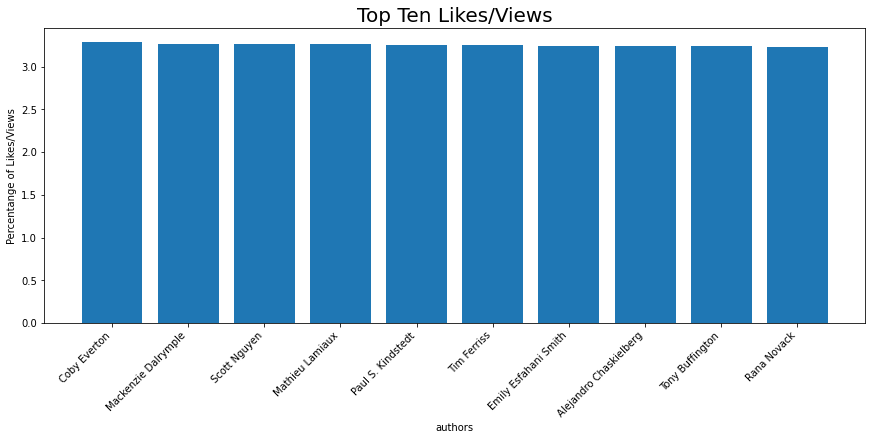

In [19]:
fig, ax = plt.subplots(layout='constrained', figsize=(12,6))
ax.bar(top_10_percentange['author'],top_10_percentange['percent_of_likes/views'])
labels = ax.get_xticklabels()
plt.setp(labels, rotation=45, horizontalalignment='right')
plt.title('Top Ten Likes/Views', fontsize=20)
plt.xlabel('authors')
plt.ylabel('Percentange of Likes/Views')
plt.show()

In [20]:
top_ten_autohor = df.pivot_table(columns=['author'], aggfunc='size').nlargest(n=10)
top_ten_autohor

author
Alex Gendler        45
Iseult Gillespie    33
Matt Walker         18
Alex Rosenthal      15
Elizabeth Cox       13
Emma Bryce          12
Daniel Finkel       11
Juan Enriquez       11
Dan Finkel           9
Greg Gage            9
dtype: int64

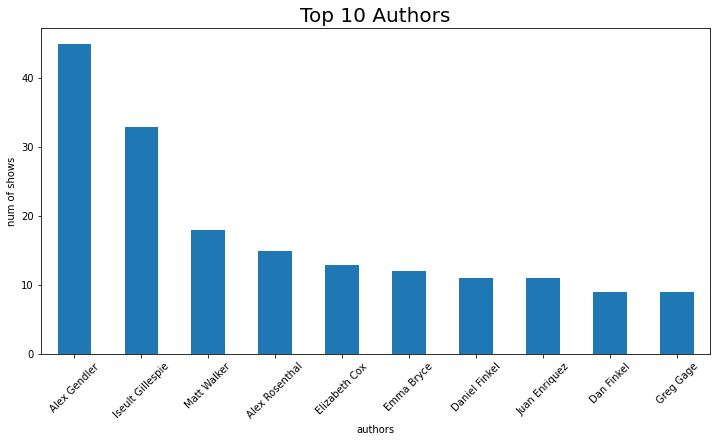

In [21]:
top_ten_autohor.plot.bar(stacked=True,rot=45,figsize=(12,6))
plt.title('Top 10 Authors', fontsize=20)
plt.xlabel('authors')
plt.ylabel('num of shows')
plt.show()

In [22]:
top_author_by_views = df.groupby("author").agg({"title": "count", "likes":"sum", "views":"sum"}).nlargest(10,'views')['views']
top_author_by_views

author
Alex Gendler        187196000
Sir Ken Robinson     95654000
Bill Gates           77800000
Simon Sinek          74800000
Brené Brown          72000000
Julian Treasure      64300000
Amy Cuddy            64000000
Tim Urban            60000000
Iseult Gillespie     54998000
Mia Nacamulli        44174000
Name: views, dtype: int64

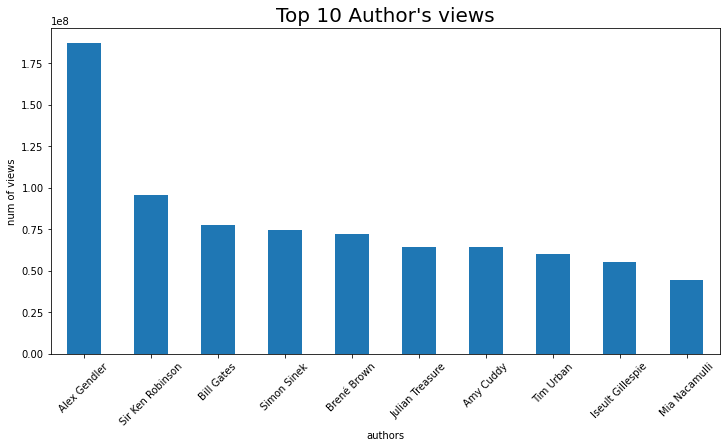

In [23]:
top_author_by_views.plot.bar(stacked=True,rot=45,figsize=(12,6))
plt.title("Top 10 Author's views", fontsize=20)
plt.xlabel('authors')
plt.ylabel('num of views')
plt.show()

In [24]:
top_author_by_likes = df.groupby("author").agg({"title": "count", "likes":"sum", "views":"sum"}).nlargest(10,'likes')['likes']
top_author_by_likes

author
Alex Gendler        5691000
Sir Ken Robinson    2833600
Bill Gates          2349000
Simon Sinek         2246000
Brené Brown         2204000
Amy Cuddy           1900000
Julian Treasure     1870000
Tim Urban           1800000
Iseult Gillespie    1660900
Mia Nacamulli       1395000
Name: likes, dtype: int64

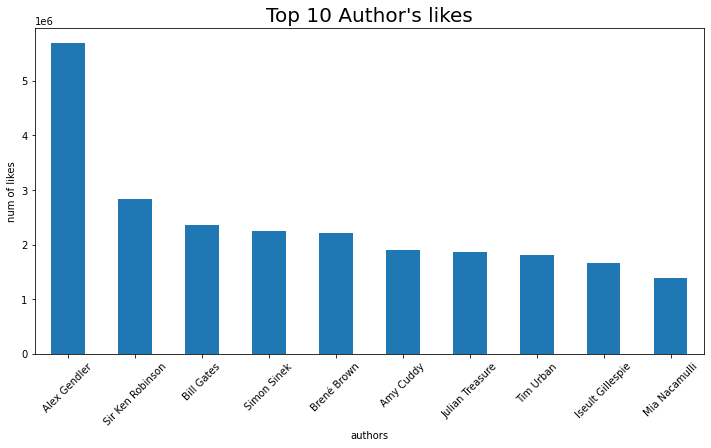

In [25]:
top_author_by_likes.plot.bar(stacked=True,rot=45,figsize=(12,6))
plt.title("Top 10 Author's likes", fontsize=20)
plt.xlabel('authors')
plt.ylabel('num of likes')
plt.show()

In [26]:
df["month"] = df.date.apply(lambda x: x.split()[0])
df["Year"] = df.date.apply(lambda x: x.split()[1])

In [27]:
showonmonths = df["month"].value_counts()

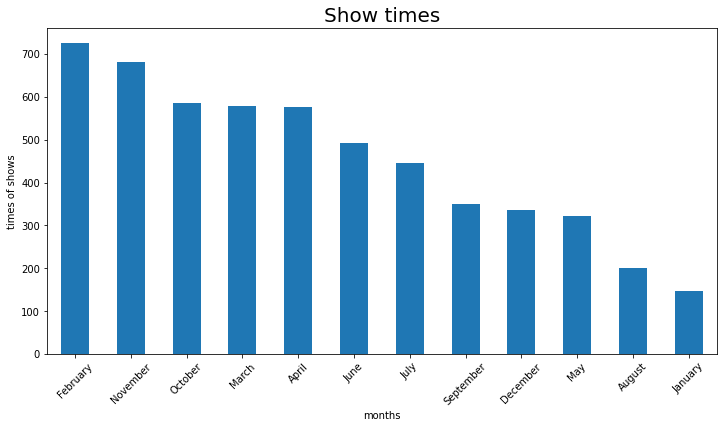

In [28]:
showonmonths.plot.bar(stacked=True,rot=45,figsize=(12,6))
plt.title("Show times", fontsize=20)
plt.xlabel('months')
plt.ylabel('times of shows')
plt.show()

In [29]:
showonyears = df["Year"].value_counts().sort_index(ascending=False)

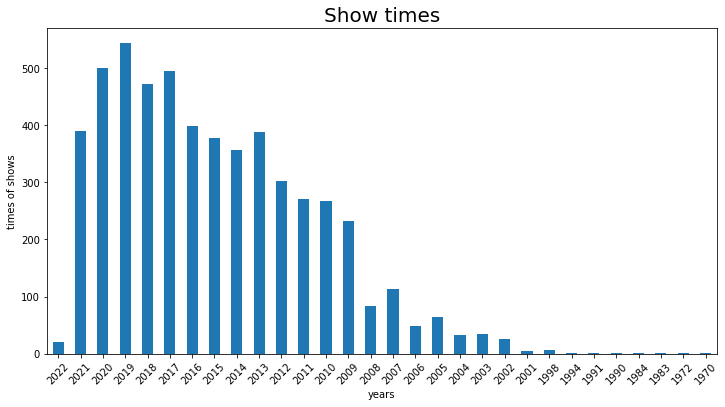

In [30]:
showonyears.plot.bar(stacked=True,rot=45,figsize=(12,6))
plt.title("Show times", fontsize=20)
plt.xlabel('years')
plt.ylabel('times of shows')
plt.show()

In [31]:
"""months = ["January", "February", "March", "April", "May", "June", 
          "July", "August", "September", "October", "November", "December"]
data_month = showonmonths.loc[months]
data_month
"""

'months = ["January", "February", "March", "April", "May", "June", \n          "July", "August", "September", "October", "November", "December"]\ndata_month = showonmonths.loc[months]\ndata_month\n'

To Create this analysis I used @mishayakovlev (https://www.kaggle.com/code/mishayakovlev/ted-talks-dataset-meaning) work. So I owe thank to him.